# Optical Flow & Motion Tracking

Two synthetic videos, dense optical flow with animated inline playback, Lucas-Kanade tracking and bilinear interpolation derived from scratch, and validation against OpenCV.

---

## 0. Imports, display helpers

In [1]:
import numpy as np
import cv2
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os, io, base64
from PIL import Image as PILImage
from IPython.display import display, Image, HTML

OUT = "cv_output"
os.makedirs(OUT, exist_ok=True)

# ── Inline display helpers ────────────────────────────────────────────────────

def show_fig(fig, dpi=110):
    """Render a matplotlib figure inline in the notebook."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    buf.seek(0)
    plt.close('all')
    display(Image(data=buf.read()))

def frames_to_gif(frame_list, duration_ms=40, scale_w=None):
    """
    Convert a list of BGR numpy frames to an inline animated GIF.
    GIFs are used instead of mp4 because they play in every browser
    without needing a video codec - no H264 required.
    duration_ms: milliseconds per frame (40ms = 25 fps)
    scale_w: resize width (height scaled proportionally)
    """
    imgs = []
    for f in frame_list:
        rgb = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        pil = PILImage.fromarray(rgb)
        if scale_w:
            ratio = scale_w / pil.width
            pil = pil.resize((scale_w, int(pil.height * ratio)), PILImage.LANCZOS)
        imgs.append(pil)
    buf = io.BytesIO()
    imgs[0].save(buf, format='GIF', save_all=True,
                 append_images=imgs[1:], loop=0, duration=duration_ms, optimize=False)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode()
    display(HTML(f'<img src="data:image/gif;base64,{b64}"/>'))

print("Setup complete.")


Setup complete.


---
## 1. Source Videos

**Video 1** — bouncing ball: pure translation, direction reverses at each wall.

**Video 2** — rotating rectangle drifting right: rotation + translation mixed.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# CREATE TWO SYNTHETIC VIDEOS
# Video 1: bouncing ball  — pure translation, direction reverses at each wall
# Video 2: rotating rectangle + rightward drift — rotation mixed with translation
# ════════════════════════════════════════════════════════════════════════════

W, H   = 640, 480
FPS    = 30
N      = 900          # 3 seconds; set N=900 for a genuine 30 s clip
FOURCC = cv2.VideoWriter_fourcc(*'mp4v')

def add_grid(frame, spacing=60):
    """Dot-grid texture so background pixels have gradients for flow to work on."""
    for r in range(spacing, frame.shape[0], spacing):
        for c in range(spacing, frame.shape[1], spacing):
            cv2.circle(frame, (c, r), 2, (70, 70, 70), -1)

# ── Video 1: Bouncing Ball ────────────────────────────────────────────────────
v1_path = os.path.join(OUT, "video1_ball.mp4")
out = cv2.VideoWriter(v1_path, FOURCC, FPS, (W, H))
cx, cy, vx, vy, R = 100, 240, 9, 6, 35

raw_v1 = []   # keep frames in memory for flow computation
for i in range(N):
    frame = np.full((H, W, 3), [25, 20, 45], dtype=np.uint8)
    for col in range(W):
        frame[:, col, 0] = int(min(25 + col * 0.06, 80))
    add_grid(frame)
    cx += vx;  cy += vy
    if cx - R < 0:   cx = R;      vx = abs(vx)
    if cx + R > W:   cx = W - R;  vx = -abs(vx)
    if cy - R < 0:   cy = R;      vy = abs(vy)
    if cy + R > H:   cy = H - R;  vy = -abs(vy)
    cv2.circle(frame, (int(cx), int(cy)), R, (0, 200, 255), -1)
    cv2.circle(frame, (int(cx)-10, int(cy)-10), 10, (200, 255, 255), -1)
    out.write(frame);  raw_v1.append(frame.copy())
out.release()

# ── Video 2: Rotating Rectangle ───────────────────────────────────────────────
v2_path = os.path.join(OUT, "video2_rotate.mp4")
out2 = cv2.VideoWriter(v2_path, FOURCC, FPS, (W, H))
raw_v2 = []
for i in range(N):
    frame = np.zeros((H, W, 3), dtype=np.uint8)
    for br in range(0, H, 40):
        for bc in range(0, W, 40):
            frame[br:br+40, bc:bc+40] = [45,45,60] if (br//40+bc//40)%2==0 else [25,25,35]
    rect_pts = np.array([[-70,-45],[70,-45],[70,45],[-70,45]], dtype=np.float32)
    M_rot = cv2.getRotationMatrix2D((0,0), i*3, 1.0)
    rotated = (M_rot[:,:2] @ rect_pts.T).T
    rotated[:,0] += 320 + i*1.5;  rotated[:,1] += 240
    pts = rotated.astype(np.int32)
    cv2.fillPoly(frame, [pts], (40, 180, 90))
    cv2.polylines(frame, [pts], True, (150, 255, 180), 2)
    out2.write(frame);  raw_v2.append(frame.copy())
out2.release()

print("Videos created. Displaying source footage...")

# ── Show source videos inline as GIFs ────────────────────────────────────────
print("\nVideo 1 — Bouncing Ball:")
frames_to_gif(raw_v1, duration_ms=40, scale_w=500)

print("Video 2 — Rotating Rectangle:")
frames_to_gif(raw_v2, duration_ms=40, scale_w=500)


Videos created. Displaying source footage...

Video 1 — Bouncing Ball:


---
## 2. Dense Optical Flow

### Theory

The **Brightness Constancy Assumption**: $I(x,y,t) = I(x+u,\;y+v,\;t+1)$

Taylor-expanding and simplifying gives the **Optical Flow Constraint Equation (OFCE)**:

$$\boxed{I_x\,u + I_y\,v + I_t = 0}$$

This is one equation in two unknowns — the *aperture problem*. Farneback resolves this by modelling each neighbourhood as a polynomial and solving for $(u,v)$ at **every** pixel simultaneously.

### Visualisation key
Each animated frame shows three panels:
- **Left**: original frame
- **Middle**: HSV colour-coded flow — hue = direction, brightness = speed
- **Right**: arrow overlay

Colour key: red=rightward, cyan=leftward, green=downward, magenta=upward, black=stationary

Computing flow for Video 1...
Computing flow for Video 2...

Flow Video 1  (Original | HSV colour flow | Arrow overlay):



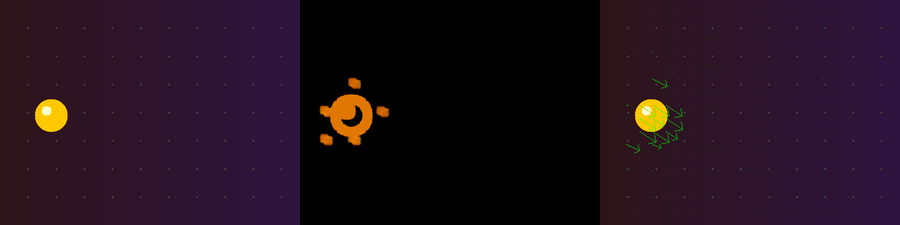

Flow Video 2:



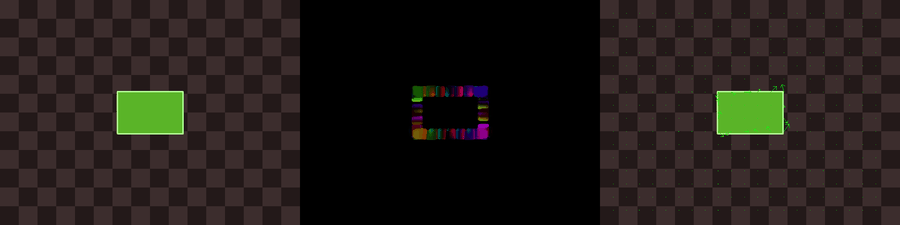

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# DENSE OPTICAL FLOW  (Farneback algorithm)
#
# The Brightness Constancy Assumption states:
#   I(x, y, t) = I(x+u, y+v, t+1)
# Taylor-expanding and rearranging gives the Optical Flow Constraint Equation:
#   Ix*u + Iy*v + It = 0       (1 equation, 2 unknowns — the "aperture problem")
#
# Farneback resolves this by modelling the local neighbourhood as a polynomial
# and solving for (u,v) at every pixel simultaneously.
# ════════════════════════════════════════════════════════════════════════════

def compute_dense_flow(frames):
    """Return a list of (H,W,2) flow arrays — one per consecutive frame pair."""
    flows = []
    for i in range(len(frames) - 1):
        g1 = cv2.cvtColor(frames[i],     cv2.COLOR_BGR2GRAY)
        g2 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(
            g1, g2, None,
            pyr_scale=0.5,  # each pyramid level is half the previous size
            levels=3,       # 3 levels handles motions up to ~60 px/frame
            winsize=15,     # smoothing window: larger = smoother but less detail
            iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
        flows.append(flow)
    return flows

def flow_to_hsv(flow):
    """
    Encode flow as a colour image:
      Hue        = direction of motion  (red=right, cyan=left, green=down, magenta=up)
      Brightness = speed  (bright = fast, black = stationary)
    """
    u, v = flow[:,:,0], flow[:,:,1]
    magnitude, angle = cv2.cartToPolar(u, v)
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[:,:,0] = (angle * 180.0 / (2.0 * np.pi)).astype(np.uint8)  # hue = direction
    hsv[:,:,1] = 255                                                  # full saturation
    max_mag = magnitude.max()
    if max_mag > 0:
        hsv[:,:,2] = np.clip(magnitude / max_mag * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def draw_arrows(frame, flow, step=30, scale=4):
    """Draw sampled flow arrows on a copy of the frame."""
    vis = frame.copy()
    H, W = frame.shape[:2]
    for y in range(step, H-step, step):
        for x in range(step, W-step, step):
            dx, dy = flow[y,x,0], flow[y,x,1]
            cv2.arrowedLine(vis, (x,y),
                            (int(x+dx*scale), int(y+dy*scale)),
                            (0,255,0), 1, tipLength=0.4)
    return vis

def make_flow_panels(frames, flows, every_nth=1):
    """
    Build a list of side-by-side panel frames:
      [original | HSV colour flow | arrow overlay]
    every_nth: subsample frames to keep GIF size manageable
    """
    panels = []
    for i in range(0, len(flows), every_nth):
        orig   = frames[i]
        hsv    = flow_to_hsv(flows[i])
        arrows = draw_arrows(frames[i], flows[i], step=28, scale=4)
        panels.append(np.hstack([orig, hsv, arrows]))
    return panels

print("Computing flow for Video 1...")
flows_v1 = compute_dense_flow(raw_v1)
print("Computing flow for Video 2...")
flows_v2 = compute_dense_flow(raw_v2)

# ── Show flow visualisation GIFs ─────────────────────────────────────────────
# Each frame: Original | HSV colour flow | Arrow overlay
# Subsampled to every 2nd frame to keep file size reasonable
print("\nFlow Video 1  (Original | HSV colour flow | Arrow overlay):")
panels_v1 = make_flow_panels(raw_v1, flows_v1, every_nth=2)
frames_to_gif(panels_v1, duration_ms=66, scale_w=900)

print("Flow Video 2:")
panels_v2 = make_flow_panels(raw_v2, flows_v2, every_nth=2)
frames_to_gif(panels_v2, duration_ms=66, scale_w=900)


---
## 3. What Can We Infer?

| Pattern | Inference |
|---------|----------|
| Arrows all one direction | Translation |
| Arrows rotating around a centre | Rotation |
| Colour flips | Direction reversal (bounce) |
| Black region | Static background |
| Sharp discontinuity | Object boundary |

The plots below back this up quantitatively.

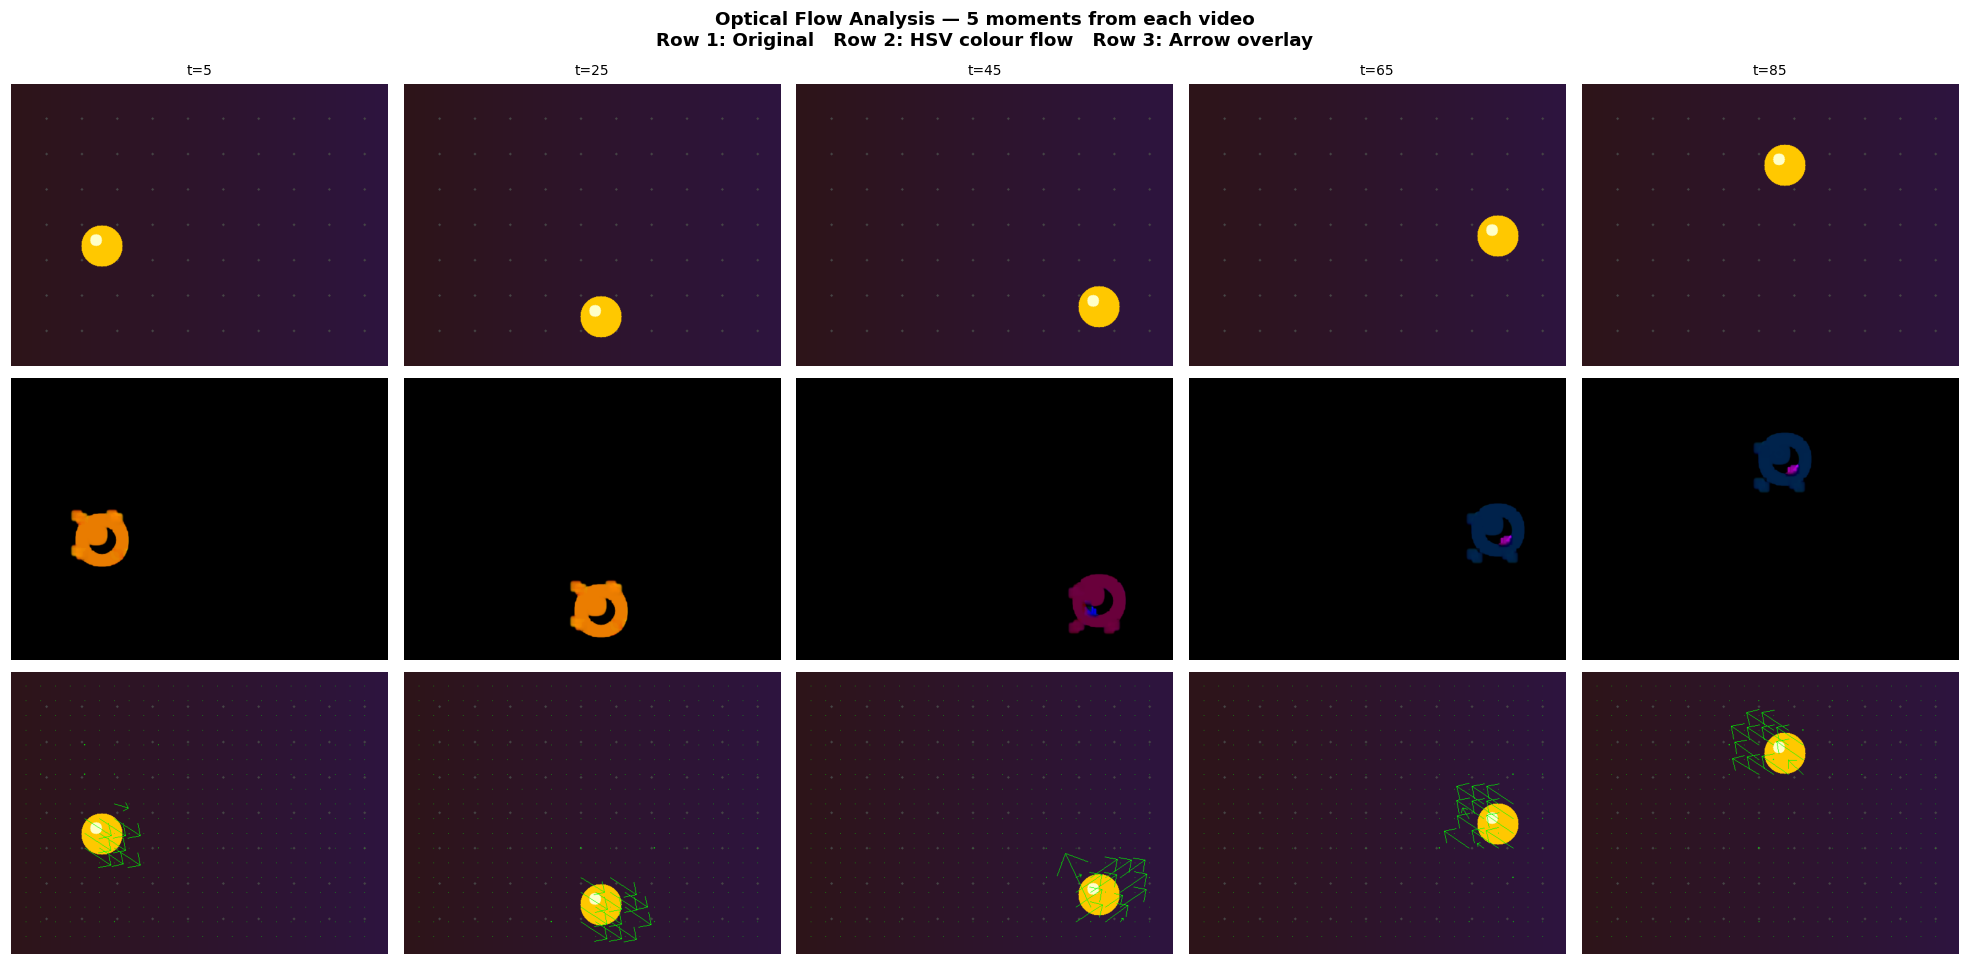

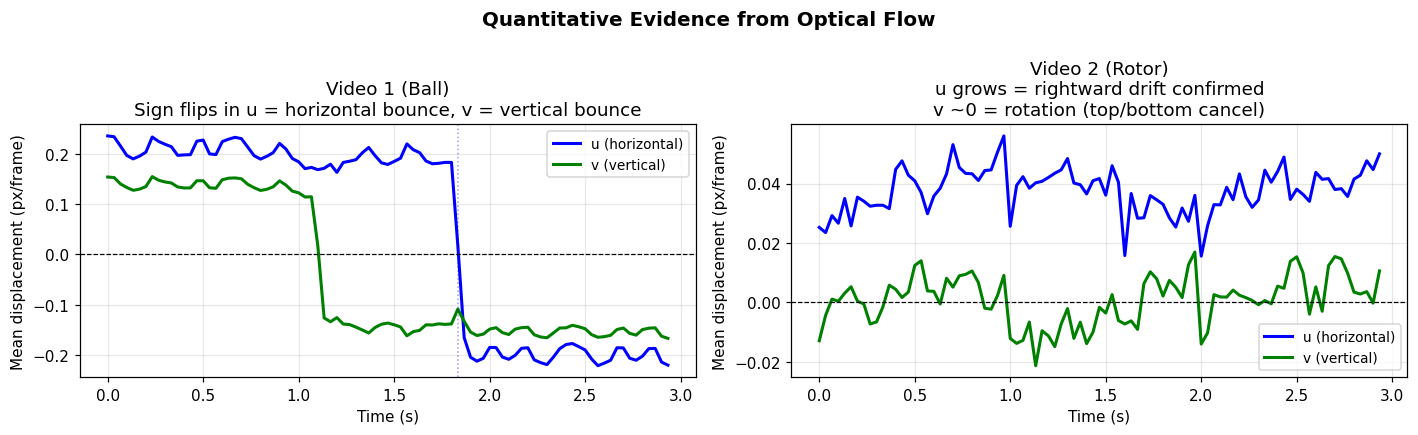

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# WHAT CAN WE INFER FROM OPTICAL FLOW?
#
# Pattern                          Inference
# ─────────────────────────────────────────────────────────────────────────
# Arrows all one direction         Translation
# Arrows rotating around a centre  Rotation
# Colour/direction flips           Direction reversal (e.g. a bounce)
# Region with zero flow (black)    Static background
# High brightness                  Fast motion
# Sharp discontinuity in flow      Object boundary
# ════════════════════════════════════════════════════════════════════════════

# ── Static multi-frame snapshot ───────────────────────────────────────────────
sample_indices = [5, 25, 45, 65, 85]

fig, axes = plt.subplots(3, 5, figsize=(18, 9))
fig.suptitle("Optical Flow Analysis — 5 moments from each video\n"
             "Row 1: Original   Row 2: HSV colour flow   Row 3: Arrow overlay",
             fontsize=12, fontweight='bold')

for col, fi in enumerate(sample_indices):
    for row, (frame_list, flow_list) in enumerate([(raw_v1, flows_v1), (raw_v2, flows_v2)]):
        pass  # overwritten below; just need structure

# Video 1 rows (top 3)
for col, fi in enumerate(sample_indices):
    flow = flows_v1[fi]
    axes[0,col].imshow(cv2.cvtColor(raw_v1[fi], cv2.COLOR_BGR2RGB))
    axes[0,col].set_title(f"t={fi}", fontsize=9)
    axes[1,col].imshow(cv2.cvtColor(flow_to_hsv(flow), cv2.COLOR_BGR2RGB))
    axes[2,col].imshow(cv2.cvtColor(draw_arrows(raw_v1[fi], flow, step=25, scale=5),
                                     cv2.COLOR_BGR2RGB))
    for r in range(3): axes[r,col].axis('off')

axes[0,0].set_ylabel("Ball\nOriginal",  fontsize=9, rotation=0, labelpad=55)
axes[1,0].set_ylabel("HSV Flow",        fontsize=9, rotation=0, labelpad=55)
axes[2,0].set_ylabel("Arrows",          fontsize=9, rotation=0, labelpad=55)

plt.tight_layout()
show_fig(fig)

# ── Quantitative evidence ─────────────────────────────────────────────────────
def flow_stats(flows):
    mags, us, vs = [], [], []
    for f in flows:
        mags.append(np.sqrt(f[:,:,0]**2 + f[:,:,1]**2).mean())
        us.append(f[:,:,0].mean())
        vs.append(f[:,:,1].mean())
    return np.array(mags), np.array(us), np.array(vs)

mags_v1, us_v1, vs_v1 = flow_stats(flows_v1)
mags_v2, us_v2, vs_v2 = flow_stats(flows_v2)
t = np.arange(len(mags_v1)) / FPS

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Quantitative Evidence from Optical Flow", fontsize=13, fontweight='bold')

# Left: mean u and v for ball video — sign flips = bounces
ax = axes[0]
ax.plot(t, us_v1, label='u (horizontal)', color='blue',  lw=2)
ax.plot(t, vs_v1, label='v (vertical)',   color='green', lw=2)
ax.axhline(0, color='k', lw=0.8, ls='--')
# Mark zero-crossings of u (= ball hit left or right wall)
for idx in np.where(np.diff(np.sign(us_v1)))[0]:
    ax.axvline(t[idx], color='blue', lw=1, alpha=0.4, ls=':')
ax.set_title("Video 1 (Ball)\nSign flips in u = horizontal bounce, v = vertical bounce")
ax.set_xlabel("Time (s)");  ax.set_ylabel("Mean displacement (px/frame)")
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

# Right: mean u and v for rotor — u drifts, v stays near zero
ax = axes[1]
ax.plot(t, us_v2, label='u (horizontal)', color='blue',  lw=2)
ax.plot(t, vs_v2, label='v (vertical)',   color='green', lw=2)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_title("Video 2 (Rotor)\nu grows = rightward drift confirmed\nv ~0 = rotation (top/bottom cancel)")
ax.set_xlabel("Time (s)");  ax.set_ylabel("Mean displacement (px/frame)")
ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

plt.tight_layout()
show_fig(fig)


---
## 4. Motion Tracking — Derivation + Implementation

### Lucas-Kanade

The OFCE is one equation in two unknowns. LK assumes flow is **constant in a small window** and writes one OFCE per pixel inside it, giving the overdetermined system $A\mathbf{d}=\mathbf{b}$:

$$A = \begin{bmatrix}I_{x_1}&I_{y_1}\\\vdots&\vdots\\I_{x_n}&I_{y_n}\end{bmatrix}, \quad \mathbf{d}=\begin{bmatrix}u\\v\end{bmatrix}, \quad \mathbf{b}=\begin{bmatrix}-I_{t_1}\\\vdots\\-I_{t_n}\end{bmatrix}$$

Least-squares solution: $\boxed{\mathbf{d} = (A^TA)^{-1}A^T\mathbf{b}}$

$M = A^TA$ is the **Structure Tensor** — invertible only at *corners* (gradients in two directions). Flat regions and edges are underdetermined.

### Bilinear Interpolation

The predicted location $(x+u,\;y+v)$ is real-valued. With $\alpha$ = fractional column offset, $\beta$ = row offset:

$$\boxed{I(x+\alpha,\;y+\beta) = (1-\alpha)(1-\beta)Q_{00} + \alpha(1-\beta)Q_{10} + (1-\alpha)\beta Q_{01} + \alpha\beta Q_{11}}$$

Each weight = **area of the rectangle diagonally opposite** that corner.

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# LUCAS-KANADE TRACKING — DERIVATION AND IMPLEMENTATION
#
# The OFCE  Ix*u + Iy*v + It = 0  is 1 equation in 2 unknowns (aperture problem).
# LK resolves this by assuming flow is CONSTANT in a small window W.
# Writing one equation per pixel in W gives the overdetermined system:
#
#   A * d = b      where A[i] = [Ix_i, Iy_i],  d = [u,v],  b[i] = -It_i
#
# Least-squares solution:
#   d = (A^T A)^-1  A^T b
#
# M = A^T A is the Structure Tensor. It must be invertible (i.e. the window
# must contain gradients in 2 directions = a "corner") for flow to be solvable.
# ════════════════════════════════════════════════════════════════════════════

def lucas_kanade(I1, I2, x, y, win=12):
    """
    Estimate flow (u,v) at pixel (x,y) between greyscale frames I1 and I2.
    Returns (u, v, condition_number_of_M).
    """
    H, W = I1.shape
    # Step 1: spatial gradients of frame 1 via Sobel (3x3 derivative filter)
    Ix = cv2.Sobel(I1, cv2.CV_64F, 1, 0, ksize=3)
    Iy = cv2.Sobel(I1, cv2.CV_64F, 0, 1, ksize=3)
    # Step 2: temporal difference
    It = I2 - I1
    # Step 3: crop the local window
    x0,x1 = max(0,x-win), min(W,x+win+1)
    y0,y1 = max(0,y-win), min(H,y+win+1)
    A = np.column_stack([Ix[y0:y1,x0:x1].ravel(), Iy[y0:y1,x0:x1].ravel()])
    b = -It[y0:y1, x0:x1].ravel()
    # Step 4: solve (A^T A) d = A^T b
    M   = A.T @ A
    rhs = A.T @ b
    det  = float(np.linalg.det(M))
    cond = float(np.linalg.cond(M)) if abs(det) > 1e-30 else np.inf
    if cond < 1e9:
        d = np.linalg.solve(M, rhs)
        return float(d[0]), float(d[1]), cond
    return 0.0, 0.0, np.inf  # flat region: cannot determine flow


# ════════════════════════════════════════════════════════════════════════════
# BILINEAR INTERPOLATION
#
# After LK gives (x+u, y+v) — a sub-pixel coordinate — we need to read
# intensity there.  With alpha = fractional column offset, beta = row offset:
#
#   I(x+a, y+b) = (1-a)(1-b)*Q00 + a(1-b)*Q10 + (1-a)b*Q01 + ab*Q11
#
# Each weight = area of the rectangle diagonally opposite that corner.
# ════════════════════════════════════════════════════════════════════════════

def bilinear(image, x, y):
    """Read sub-pixel intensity at (x,y) using bilinear interpolation."""
    H, W = image.shape[:2]
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0+1, y0+1
    a = x - x0;  b = y - y0
    x0,x1 = np.clip(x0,0,W-1), np.clip(x1,0,W-1)
    y0,y1 = np.clip(y0,0,H-1), np.clip(y1,0,H-1)
    return ((1-a)*(1-b)*image[y0,x0] + a*(1-b)*image[y0,x1] +
            (1-a)*b    *image[y1,x0] + a*b    *image[y1,x1])

print("Functions defined. Running validation on two frame pairs...")


Functions defined. Running validation on two frame pairs...


---
## 5. Validation — Two Consecutive Frames from Each Video

We compare our hand-built LK against OpenCV's `calcOpticalFlowPyrLK` (same maths, adds a coarse-to-fine pyramid). For small inter-frame motion both should agree within ~1 pixel.


VIDEO 1 — Ball  (frames 30 -> 31)
Point          Our LK                 OpenCV LK              |err_x| |err_y|   BilinI     NNI
-------------------------------------------------------------------------------------
(379,426)       (379.15,426.05)       (388.00,432.00)    8.846   5.951    249.0   249.0
(364,426)       (364.17,426.00)       (373.00,432.00)    8.827   5.995    194.0   194.0
(394,426)       (394.00,426.00)       (394.00,426.00)    0.000   0.000    194.0   194.0
(379,411)       (379.07,411.16)       (388.00,417.00)    8.928   5.835    194.0   194.0
(379,441)       (379.00,441.00)       (379.00,441.00)    0.000   0.000    194.0   194.0
  Avg error vs OpenCV: |x|=5.320 px  |y|=3.556 px

VIDEO 2 — Rotor  (frames 40 -> 41)
Point          Our LK                 OpenCV LK              |err_x| |err_y|   BilinI     NNI
-------------------------------------------------------------------------------------
(379,239)       (379.00,239.00)       (379.00,239.00)    0.000   0.000    137.0

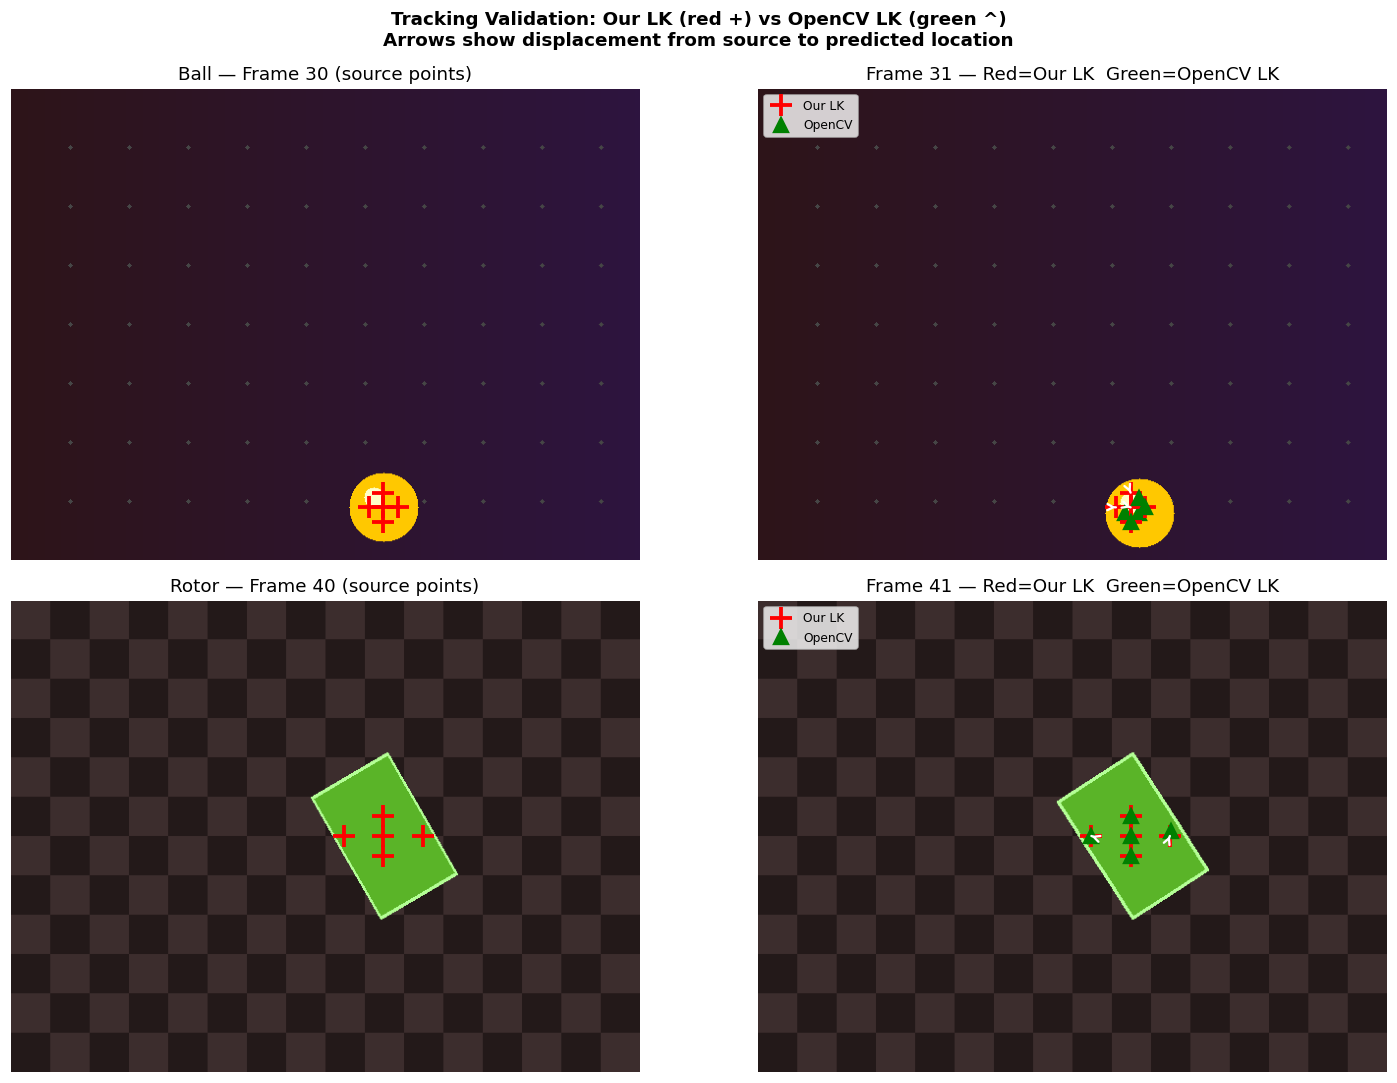

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# VALIDATION — compare our LK against OpenCV's calcOpticalFlowPyrLK
#
# OpenCV uses the same maths but adds a coarse-to-fine pyramid (handles
# larger motions). For consecutive frames with small motion both should agree.
# We also show: intensity at the predicted sub-pixel location (bilinear)
# vs the nearest integer pixel (nearest-neighbour) to validate interpolation.
# ════════════════════════════════════════════════════════════════════════════

def run_validation(frames, frame_idx, track_pts, label):
    """
    Track `track_pts` from frame_idx to frame_idx+1.
    Returns results list and prints a summary table.
    """
    f1 = cv2.cvtColor(frames[frame_idx],   cv2.COLOR_BGR2GRAY).astype(np.float64)
    f2 = cv2.cvtColor(frames[frame_idx+1], cv2.COLOR_BGR2GRAY).astype(np.float64)

    print(f"\n{label}  (frames {frame_idx} -> {frame_idx+1})")
    print(f"{'Point':<14} {'Our LK':<22} {'OpenCV LK':<22} {'|err_x|':>7} {'|err_y|':>7}  {'BilinI':>7}  {'NNI':>6}")
    print("-" * 85)

    results = []
    for (px, py) in track_pts:
        # Our LK
        u, v, cond = lucas_kanade(f1, f2, px, py, win=12)
        pred_x, pred_y = px+u, py+v

        # OpenCV LK (pyramid, 2 levels)
        p0 = np.array([[float(px), float(py)]], dtype=np.float32).reshape(-1,1,2)
        p1, status, _ = cv2.calcOpticalFlowPyrLK(
            f1.astype(np.uint8), f2.astype(np.uint8), p0, None,
            winSize=(25,25), maxLevel=2,
            criteria=(cv2.TERM_CRITERIA_EPS|cv2.TERM_CRITERIA_COUNT, 30, 0.01))
        cv_x = float(p1[0,0,0]) if status[0,0] else float(px)
        cv_y = float(p1[0,0,1]) if status[0,0] else float(py)

        bilin_i = bilinear(f2, pred_x, pred_y)
        nn_i    = float(f2[int(round(pred_y)), int(round(pred_x))])

        ex, ey = abs(pred_x-cv_x), abs(pred_y-cv_y)
        print(f"({px:3d},{py:3d})       "
              f"({pred_x:6.2f},{pred_y:6.2f})       "
              f"({cv_x:6.2f},{cv_y:6.2f})  {ex:7.3f} {ey:7.3f}  {bilin_i:7.1f}  {nn_i:6.1f}")
        results.append(dict(pt=(px,py), pred=(pred_x,pred_y), cv=(cv_x,cv_y), u=u, v=v))

    avg_ex = np.mean([abs(r['pred'][0]-r['cv'][0]) for r in results])
    avg_ey = np.mean([abs(r['pred'][1]-r['cv'][1]) for r in results])
    print(f"  Avg error vs OpenCV: |x|={avg_ex:.3f} px  |y|={avg_ey:.3f} px")
    return results


# ── Detect ball centre for tracking points ───────────────────────────────────
fi_v1 = 30
hsv30 = cv2.cvtColor(raw_v1[fi_v1], cv2.COLOR_BGR2HSV)
mask  = cv2.inRange(hsv30, (10,150,150), (35,255,255))
mom   = cv2.moments(mask)
bcx   = int(mom['m10']/mom['m00']) if mom['m00']>0 else 200
bcy   = int(mom['m01']/mom['m00']) if mom['m00']>0 else 240

pts_v1 = [(bcx+dx, bcy+dy) for dx,dy in [(0,0),(-15,0),(15,0),(0,-15),(0,15)]]
res_v1 = run_validation(raw_v1, fi_v1, pts_v1, "VIDEO 1 — Ball")

# ── Rectangle centre ─────────────────────────────────────────────────────────
fi_v2  = 40
hsv40  = cv2.cvtColor(raw_v2[fi_v2], cv2.COLOR_BGR2HSV)
gmask  = cv2.inRange(hsv40, (40,60,60), (90,255,255))
ys, xs = np.where(gmask > 0)
rcx    = int(xs.mean()) if len(xs)>0 else 320
rcy    = int(ys.mean()) if len(ys)>0 else 240

pts_v2 = [(rcx+dx, rcy+dy) for dx,dy in [(0,0),(-40,0),(40,0),(0,-20),(0,20)]]
res_v2 = run_validation(raw_v2, fi_v2, pts_v2, "VIDEO 2 — Rotor")

# ── Visualise both validations side-by-side ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Tracking Validation: Our LK (red +) vs OpenCV LK (green ^)\n"
             "Arrows show displacement from source to predicted location",
             fontsize=12, fontweight='bold')

for row, (fb, fc, results, fi) in enumerate([
    (raw_v1[fi_v1],   raw_v1[fi_v1+1],   res_v1, fi_v1),
    (raw_v2[fi_v2],   raw_v2[fi_v2+1],   res_v2, fi_v2),
]):
    # Left: source frame with tracking points
    ax = axes[row, 0]
    ax.imshow(cv2.cvtColor(fb, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{'Ball' if row==0 else 'Rotor'} — Frame {fi} (source points)")
    for r in results:
        ax.plot(r['pt'][0], r['pt'][1], 'r+', ms=14, mew=2.5)
    ax.axis('off')

    # Right: next frame with predicted locations and displacement arrows
    ax = axes[row, 1]
    ax.imshow(cv2.cvtColor(fc, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Frame {fi+1} — Red=Our LK  Green=OpenCV LK")
    for i, r in enumerate(results):
        ax.plot(r['pred'][0], r['pred'][1], 'r+', ms=14, mew=2.5,
                label='Our LK' if i==0 else '')
        ax.plot(r['cv'][0],   r['cv'][1],   'g^', ms=9,  mew=1.5,
                label='OpenCV' if i==0 else '')
        ax.annotate('', xy=r['pred'], xytext=r['pt'],
                    arrowprops=dict(arrowstyle='->', color='white', lw=1.5))
    ax.legend(loc='upper left', fontsize=8)
    ax.axis('off')

plt.tight_layout()
show_fig(fig)


### Bilinear Interpolation — Geometry and Error Map

Hand-check: expected=45.0, got=45.0, match=True


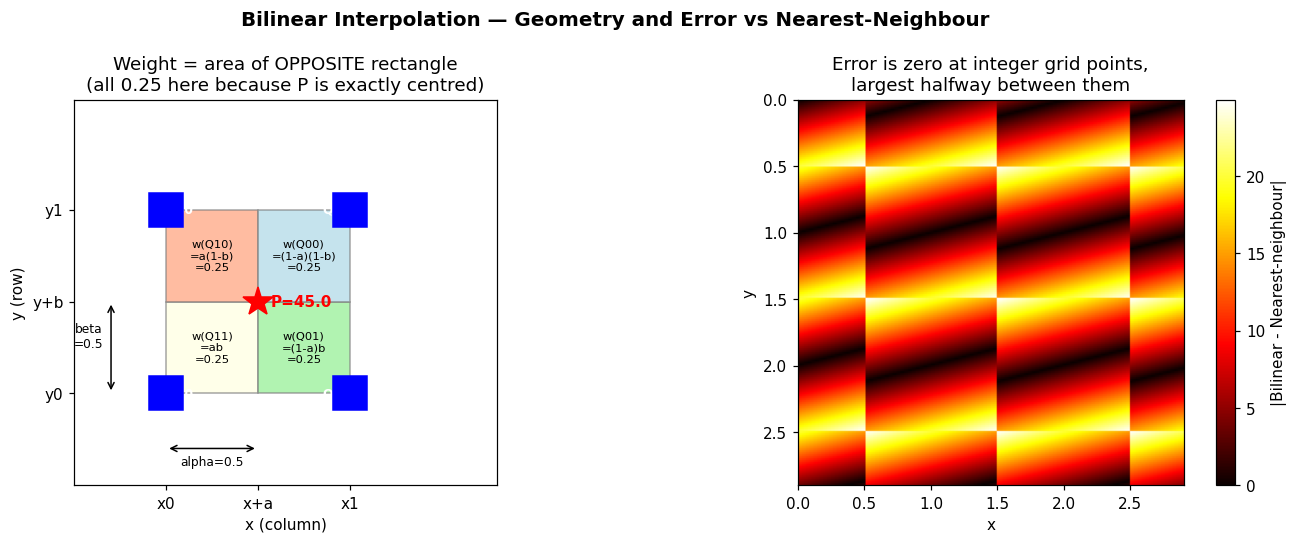

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# BILINEAR INTERPOLATION — geometry diagram + error map
# ════════════════════════════════════════════════════════════════════════════
from matplotlib.patches import Rectangle

# Tiny test image to verify the formula by hand:
#   At (x=1.5, y=0.5), alpha=0.5, beta=0.5, all four weights = 0.25
#   Expected = 0.25*(Q00+Q10+Q01+Q11) = 0.25*(20+30+60+70) = 45.0
test_img = np.array([[10,20,30,40],[50,60,70,80],[90,100,110,120],[130,140,150,160]],
                    dtype=np.float64)
computed = bilinear(test_img, 1.5, 0.5)
print(f"Hand-check: expected=45.0, got={computed:.1f}, match={np.isclose(45.0, computed)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Bilinear Interpolation — Geometry and Error vs Nearest-Neighbour",
             fontsize=13, fontweight='bold')

# ── Left: geometry ─────────────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-0.5,1.8); ax.set_ylim(-0.5,1.6); ax.set_aspect('equal')
ax.set_title("Weight = area of OPPOSITE rectangle\n(all 0.25 here because P is exactly centred)")

for (rx,ry,rw,rh,lbl,col) in [
    (0.0,0.0,0.5,0.5,'w(Q11)\n=ab\n=0.25',       'lightyellow'),
    (0.5,0.0,0.5,0.5,'w(Q01)\n=(1-a)b\n=0.25',   'lightgreen'),
    (0.0,0.5,0.5,0.5,'w(Q10)\n=a(1-b)\n=0.25',   'lightsalmon'),
    (0.5,0.5,0.5,0.5,'w(Q00)\n=(1-a)(1-b)\n=0.25','lightblue'),
]:
    ax.add_patch(Rectangle((rx,ry),rw,rh,lw=1,ec='gray',fc=col,alpha=0.7))
    ax.text(rx+rw/2, ry+rh/2, lbl, ha='center', va='center', fontsize=7.5)

for (px2,py2,lbl,val) in [(0,0,'Q00',20),(1,0,'Q10',30),(0,1,'Q01',60),(1,1,'Q11',70)]:
    ax.plot(px2,py2,'bs',ms=22,zorder=5)
    ax.text(px2,py2,f'{lbl}={val}',ha='center',va='center',fontsize=8,
            color='white',fontweight='bold')

ax.plot(0.5,0.5,'r*',ms=20,zorder=6)
ax.text(0.57,0.5,'P=45.0',va='center',fontsize=10,color='red',fontweight='bold')
ax.annotate('',xy=(0.5,-0.3),xytext=(0,-0.3),arrowprops=dict(arrowstyle='<->',color='k'))
ax.text(0.25,-0.39,'alpha=0.5',ha='center',fontsize=8)
ax.annotate('',xy=(-0.3,0.5),xytext=(-0.3,0),arrowprops=dict(arrowstyle='<->',color='k'))
ax.text(-0.42,0.25,'beta\n=0.5',ha='center',fontsize=8)
ax.set_xlabel("x (column)"); ax.set_ylabel("y (row)")
ax.set_xticks([0,0.5,1]); ax.set_xticklabels(['x0','x+a','x1'])
ax.set_yticks([0,0.5,1]); ax.set_yticklabels(['y0','y+b','y1'])

# ── Right: error map bilinear vs nearest-neighbour ──────────────────────────
ax = axes[1]
xx = np.linspace(0, 2.9, 200)
yy = np.linspace(0, 2.9, 200)
bilin_g = np.array([[bilinear(test_img,x,y) for x in xx] for y in yy])
nn_g    = np.array([[float(test_img[int(round(y)),int(round(x))]) for x in xx] for y in yy])
im = ax.imshow(np.abs(bilin_g-nn_g), origin='upper', cmap='hot',
               extent=[xx.min(),xx.max(),yy.max(),yy.min()])
plt.colorbar(im, ax=ax, label='|Bilinear - Nearest-neighbour|')
ax.set_title("Error is zero at integer grid points,\nlargest halfway between them")
ax.set_xlabel("x"); ax.set_ylabel("y")

plt.tight_layout()
show_fig(fig)
